1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns


2. Download NSE Data

In [5]:
tickers = pd.read_csv("../Data/tickers.csv")["Tickers"]
nse_data = pd.DataFrame()
for ticker in tickers:
    nse_data[ticker] = yf.download(ticker, start="2021-01-01", auto_adjust=False)["Adj Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

3. Price Normalization Chart

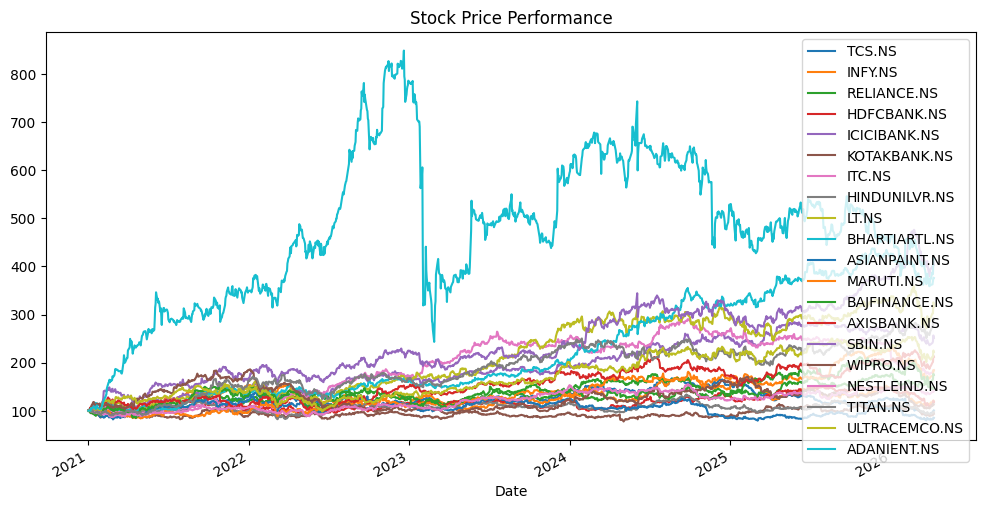

In [3]:
(nse_data/nse_data.iloc[0] * 100).plot(figsize=(12, 6))
plt.title("Stock Price Performance")
plt.show()

4. Return Calculation

In [4]:
pf_returns = nse_data.pct_change().dropna()
print(pf_returns.head())

              TCS.NS   INFY.NS  RELIANCE.NS  HDFCBANK.NS  ICICIBANK.NS  \
Date                                                                     
2021-01-04  0.037975  0.022056     0.001685    -0.006351      0.007962   
2021-01-05  0.017618  0.004308    -0.012432     0.007556      0.010438   
2021-01-06 -0.013417 -0.009043    -0.026372    -0.004311      0.017590   
2021-01-07 -0.006128 -0.015561    -0.001619    -0.003027     -0.010243   
2021-01-08  0.029049  0.039575     0.011799     0.010874      0.001756   

            KOTAKBANK.NS    ITC.NS  HINDUNILVR.NS     LT.NS  BHARTIARTL.NS  \
Date                                                                         
2021-01-04     -0.014293 -0.002104       0.016314  0.013570       0.003785   
2021-01-05     -0.002951 -0.009138       0.009911 -0.006314      -0.005995   
2021-01-06      0.005434 -0.028612      -0.013568  0.005895       0.021984   
2021-01-07     -0.009135 -0.012658      -0.020043  0.018988       0.037978   
2021-01-08   

5. Annual Returns

In [5]:
annual_returns = pf_returns.mean() * 252
print(annual_returns.head())
print(annual_returns.tail())


TCS.NS          0.023959
INFY.NS         0.065179
RELIANCE.NS     0.101535
HDFCBANK.NS     0.055812
ICICIBANK.NS    0.202942
dtype: float64
WIPRO.NS         0.058504
NESTLEIND.NS     0.083799
TITAN.NS         0.235489
ULTRACEMCO.NS    0.183490
ADANIENT.NS      0.402735
dtype: float64


6. Covariance Matrix

In [6]:
cov_matrix = pf_returns.cov() * 252
print(cov_matrix.head())

                TCS.NS   INFY.NS  RELIANCE.NS  HDFCBANK.NS  ICICIBANK.NS  \
TCS.NS        0.044956  0.036737     0.013615     0.010685      0.010154   
INFY.NS       0.036737  0.059589     0.014981     0.013724      0.013855   
RELIANCE.NS   0.013615  0.014981     0.052362     0.018126      0.018032   
HDFCBANK.NS   0.010685  0.013724     0.018126     0.046888      0.026143   
ICICIBANK.NS  0.010154  0.013855     0.018032     0.026143      0.049402   

              KOTAKBANK.NS    ITC.NS  HINDUNILVR.NS     LT.NS  BHARTIARTL.NS  \
TCS.NS            0.008736  0.006954       0.010570  0.016791       0.011616   
INFY.NS           0.010765  0.008252       0.010449  0.019511       0.014026   
RELIANCE.NS       0.018219  0.014155       0.008807  0.023818       0.016251   
HDFCBANK.NS       0.025901  0.010400       0.008703  0.023153       0.014300   
ICICIBANK.NS      0.025007  0.012597       0.007157  0.024654       0.017038   

              ASIANPAINT.NS  MARUTI.NS  BAJFINANCE.NS  AXISBAN

7. Correlation Heatmap

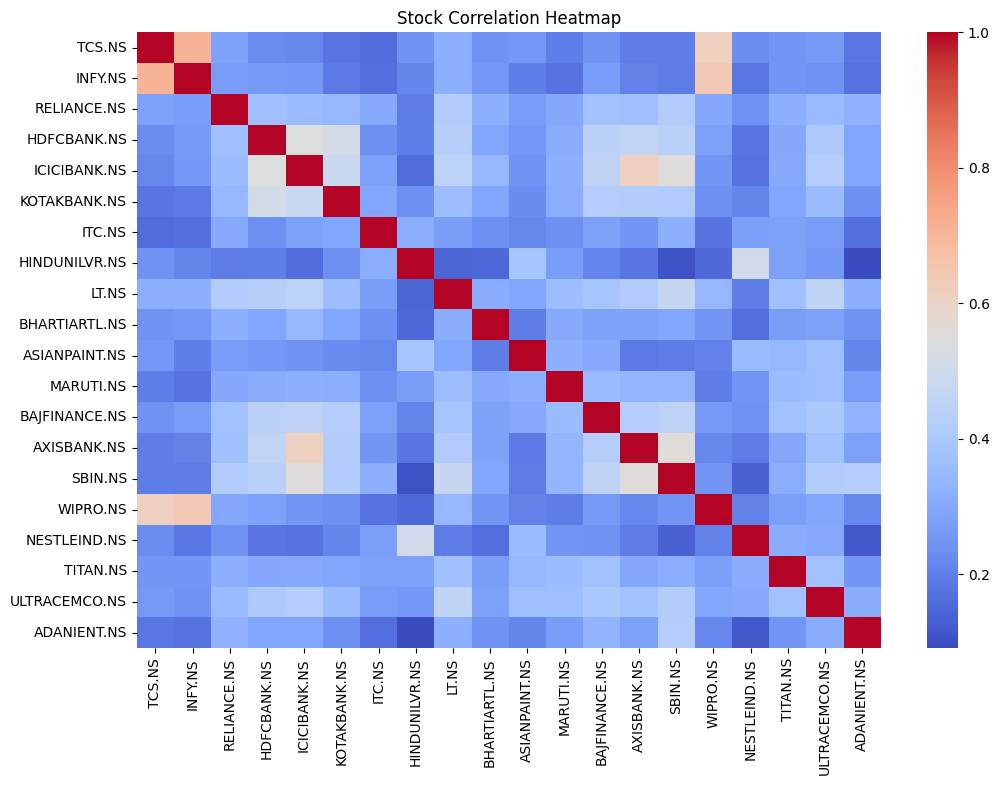

In [7]:
corr_matrix = pf_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm"
)

plt.title("Stock Correlation Heatmap")
plt.show()

8. Monte Carlo Simulation

In [8]:
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []

for i in range(10000):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    portfolio_weights.append(weights)

    returns = np.dot(weights, annual_returns)
    portfolio_returns.append(returns)

    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_volatility.append(volatility)

portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
portfolio_weights = np.array(portfolio_weights)

portfolio = pd.DataFrame({
    'Returns': portfolio_returns,
    'Volatility': portfolio_volatility
})

print(portfolio.head())

    Returns  Volatility
0  0.161088    0.152783
1  0.140025    0.148776
2  0.144857    0.143216
3  0.169086    0.153950
4  0.137218    0.140054


9. Sharpe Ratio Calculation

In [9]:
risk_free_rate = 0.06

portfolio['Sharpe Ratio'] = (portfolio['Returns'] - risk_free_rate) / portfolio['Volatility']
print(portfolio.head())
print(portfolio.tail())

    Returns  Volatility  Sharpe Ratio
0  0.161088    0.152783      0.661648
1  0.140025    0.148776      0.537888
2  0.144857    0.143216      0.592506
3  0.169086    0.153950      0.708581
4  0.137218    0.140054      0.551343
       Returns  Volatility  Sharpe Ratio
9995  0.151749    0.146155      0.627752
9996  0.146217    0.140152      0.615167
9997  0.137789    0.140860      0.552238
9998  0.151285    0.147184      0.620213
9999  0.128488    0.136896      0.500290


10. Best Portfolio

In [10]:
max_sharpe_portfolio = portfolio.iloc[portfolio['Sharpe Ratio'].idxmax()]
min_volatility_portfolio = portfolio.iloc[portfolio['Volatility'].idxmin()]

print("Maximum Sharpe Ratio Portfolio:")
print(max_sharpe_portfolio)

print("Minimum Volatility Portfolio:")
print(min_volatility_portfolio)

Maximum Sharpe Ratio Portfolio:
Returns         0.190311
Volatility      0.152078
Sharpe Ratio    0.856871
Name: 1438, dtype: float64
Minimum Volatility Portfolio:
Returns         0.129836
Volatility      0.130605
Sharpe Ratio    0.534712
Name: 1895, dtype: float64


In [11]:
best_weights = portfolio_weights[portfolio['Sharpe Ratio'].idxmax()]
allocation = pd.DataFrame({
    'Stock': tickers,
    'Weight': best_weights
})
print(allocation)

            Stock    Weight
0          TCS.NS  0.012500
1         INFY.NS  0.008308
2     RELIANCE.NS  0.017379
3     HDFCBANK.NS  0.004964
4    ICICIBANK.NS  0.074652
5    KOTAKBANK.NS  0.030889
6          ITC.NS  0.082703
7   HINDUNILVR.NS  0.019426
8           LT.NS  0.089236
9   BHARTIARTL.NS  0.084615
10  ASIANPAINT.NS  0.048742
11      MARUTI.NS  0.040857
12  BAJFINANCE.NS  0.051720
13    AXISBANK.NS  0.026093
14        SBIN.NS  0.089363
15       WIPRO.NS  0.016325
16   NESTLEIND.NS  0.108744
17       TITAN.NS  0.058831
18  ULTRACEMCO.NS  0.047239
19    ADANIENT.NS  0.087414


11. Portfolio Allocation Pie Chart

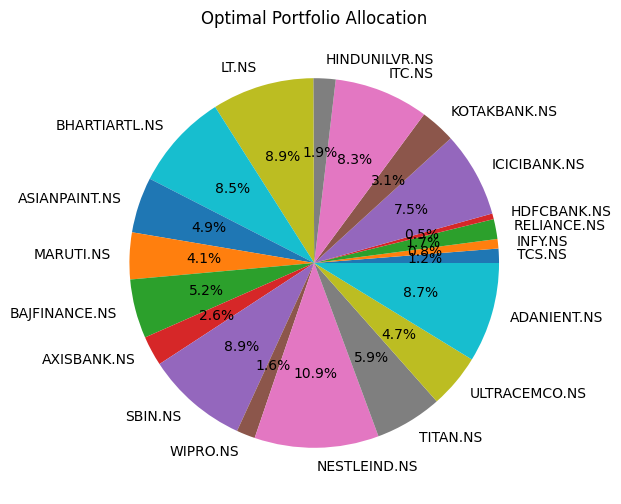

In [12]:
plt.figure(figsize=(10, 6))

plt.pie(
    allocation['Weight'],
    labels=allocation['Stock'],
    autopct='%1.1f%%'
    
)
plt.title("Optimal Portfolio Allocation")
plt.show()

12. Efficient Frontier Plot

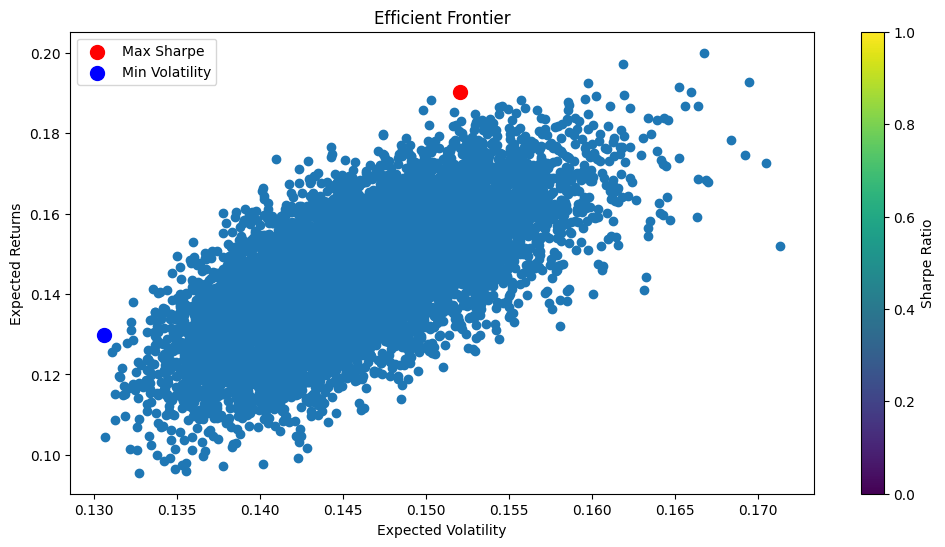

In [13]:
plt.figure(figsize=(12,6))

plt.scatter(
    portfolio["Volatility"],
    portfolio["Returns"],
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Returns"],
    color="red",
    s=100,
    label="Max Sharpe"
)

plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Returns"],
    color="blue",
    s=100,
    label="Min Volatility"
)

plt.xlabel("Expected Volatility")
plt.ylabel("Expected Returns")
plt.title("Efficient Frontier")

plt.legend()
plt.show()